In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


from kineticanalysis.generator.generator_track import (generate_tracks, generate_one_track)
from kineticanalysis.analysis.analysis_track import single_track_analysis, check_track_validity

In [2]:
prot_aa_size = {
    "32xsuntag": 796,  #768/32=24 , left 28
    "linker": 4,
    "twist": 490,
    "ilp4": 134,
    "snail": 390,
    "similar_prot":800,
    "very_long_prot":3000, 
}

In [3]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["similar_prot"]
elongation_rate = 5

In [4]:
for i in range(10):
    x_global, y_global, y_start_prot = generate_one_track(prot_length = prot_aa_size["very_long_prot"], 
                                                      suntag_length = prot_aa_size["32xsuntag"], 
                                                      nb_suntag=32, 
                                                      fluo_one_suntag=4, 
                                                      translation_rate=elongation_rate, 
                                                      binding_rate=0.05,
                                                      step = 0.1,
                                                      length=85000, 
                                                       remove_point_beginning=10000)
    if i == 0:
        datas_rand = pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                        "y_start" :y_start_prot,
                          "TRACK_ID" : i
                             })
    else:
        datas_rand = pd.concat([datas_rand, 
                           pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                         "y_start" :y_start_prot,
                          "TRACK_ID" : i
                             })], ignore_index=True)

# datas.to_csv(os.path.join(path, "datas_track_length_translation_rate_5_long.csv"))

In [5]:
for i in range(10):
    x_global, y_global, y_start_prot = generate_one_track(prot_length = prot_aa_size["very_long_prot"], 
                                                      suntag_length = prot_aa_size["32xsuntag"], 
                                                      nb_suntag=32, 
                                                      fluo_one_suntag=4, 
                                                      translation_rate=elongation_rate, 
                                                      binding_rate=0.05,
                                                      step = 0.1,
                                                      length=85000, 
                                                       remove_point_beginning=10000,
                                                         footprint=10)
    if i == 0:
        datas_queue = pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                              "y_start" :y_start_prot,
                          "TRACK_ID" : i
                             })
    else:
        datas_queue = pd.concat([datas_queue, 
                           pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                             "y_start" :y_start_prot,
                          "TRACK_ID" : i
                             })], ignore_index=True)

# datas.to_csv(os.path.join(path, "datas_track_length_translation_rate_5_long.csv"))

/tmp/ipykernel_3065895/3462083946.py:3: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  ax.plot(datas_rand.groupby("FRAME").mean()["y_start"][::10][:6000])
/tmp/ipykernel_3065895/3462083946.py:4: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  ax.plot(datas_queue.groupby("FRAME").mean()["y_start"][::10][:6000])


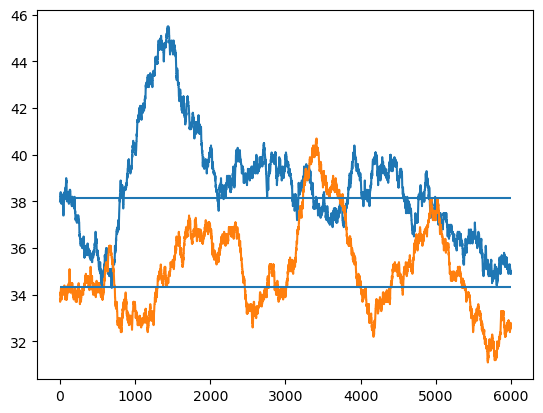

In [6]:
fig, ax = plt.subplots()

ax.plot(datas_rand.groupby("FRAME").mean()["y_start"][::10][:6000])
ax.plot(datas_queue.groupby("FRAME").mean()["y_start"][::10][:6000])

ax.hlines(datas_rand.mean()["y_start"], 0, 6000)
ax.hlines(datas_queue.mean()["y_start"], 0, 6000)

# fig.savefig("mean_rib_occupancy_time.eps")

In [7]:
ft_all = [1]
ft_all.extend(np.arange(5,100,5))
ft_all = np.array(ft_all)
len(ft_all)

20

In [8]:
# Fit vs rib density
cpt= 0

ft_all = [1]
ft_all.extend(np.arange(5,100,5))
ft_all = np.array(ft_all)
elongation_rate = 0.1
for ft in ft_all:
    for i in range(5):
        x_global, y_global, y_start_prot = generate_one_track(prot_length = prot_aa_size["very_long_prot"], 
                                                          suntag_length = prot_aa_size["32xsuntag"], 
                                                          nb_suntag=32, 
                                                          fluo_one_suntag=4, 
                                                          translation_rate=elongation_rate, 
                                                          binding_rate=0.05,
                                                          step = 0.1,
                                                          length=85000, 
                                                           remove_point_beginning=10000,
                                                             footprint=ft)
        if cpt == 0:
            datas_fp = pd.DataFrame({"FRAME":x_global,
                              "MEAN_INTENSITY_CH1":y_global,
                                  "y_start" :y_start_prot,
                                        "foot_print":ft,
                              "TRACK_ID" : i
                                 })
            cpt+=1
        else:
            datas_fp = pd.concat([datas_fp, 
                               pd.DataFrame({"FRAME":x_global,
                              "MEAN_INTENSITY_CH1":y_global,
                                 "y_start" :y_start_prot,
                                 "foot_print":ft,
                              "TRACK_ID" : i
                                 })], ignore_index=True)

# datas_fp.to_csv("datas_foot_print_er_01.csv")

KeyboardInterrupt: 

In [ ]:
datas_fp.groupby("foot_print").mean()["y_start"]

In [43]:
datas_fp.groupby(["foot_print", "TRACK_ID"]).mean()["y_start"]

foot_print  TRACK_ID
1           0           1017.342587
            1           1024.353473
            2           1008.253280
            3           1003.761530
            4           1000.637320
                           ...     
95          0             30.962118
            1             31.038377
            2             30.957320
            3             30.925061
            4             30.955064
Name: y_start, Length: 100, dtype: float64

In [9]:
datas_fp = pd.read_csv("datas_foot_print_er_01.csv")

In [10]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["similar_prot"]
first= True
length_track = 3600
t=300
for ft in ft_all:
    for i in range(5):
        dt = t*0.1
        nb_point = int(length_track/dt)
        datas2 = datas_fp[(datas_fp["TRACK_ID"]==i) & (datas_fp["foot_print"]==ft)][::t][:nb_point]
        datas2["FRAME"] = np.arange(nb_point)
        if (len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 2):
            
            (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                   i,
                                                   normalise_intensity=1,
                                                   delta_t=dt,
                                                   rtol=1e-1,
                                                   nb_missing_point=0,
                                                   )

            
            (x_auto, y_auto, k, c,elongation_r, translation_init_r,perr) = single_track_analysis(x, 
                                                                                                 y, 
                                                                                                 delta_t = dt,
                                                                                                 protein_size=prot_aa_size["similar_prot"],
                                                                                                 suntag_size =prot_aa_size["32xsuntag"], 
                                                                                                 repetition_suntag = 32,
                                                                                                 mm=None,
                                                                                                 method="exact",
                                                                                                 # method="approx",
                                                                                                 # method="epitope",
                                                                                                 simulation=True)

            
            if first:
                results = pd.DataFrame({"elongation_r":elongation_r, 
                                        "init_translation_r":translation_init_r, 
                                        "dt":dt,
                                        "long_track":datas2.shape[0],
                                        "k":k,
                                        "c":c,
                                        "foot_print":ft,
                                        "ft":datas2["y_start"].mean(),
                                        "nb_point":nb_point,
                                       "id":i},index=[0])
                first = False
            
            else:
                results = pd.concat([results, 
                                pd.DataFrame({"elongation_r":elongation_r, 
                                              "init_translation_r":translation_init_r, 
                                              "dt":dt, 
                                              "long_track":datas2.shape[0],
                                              "k":k,
                                                "c":c,
                                              "foot_print":ft,
                                              "ft":datas2["y_start"].mean(),
                                              "length_track":length_track,
                                              "nb_point":nb_point,
                                              "id":i}, index=[0])
                                ], ignore_index=True)


Text(0, 0.5, 'Nrib')

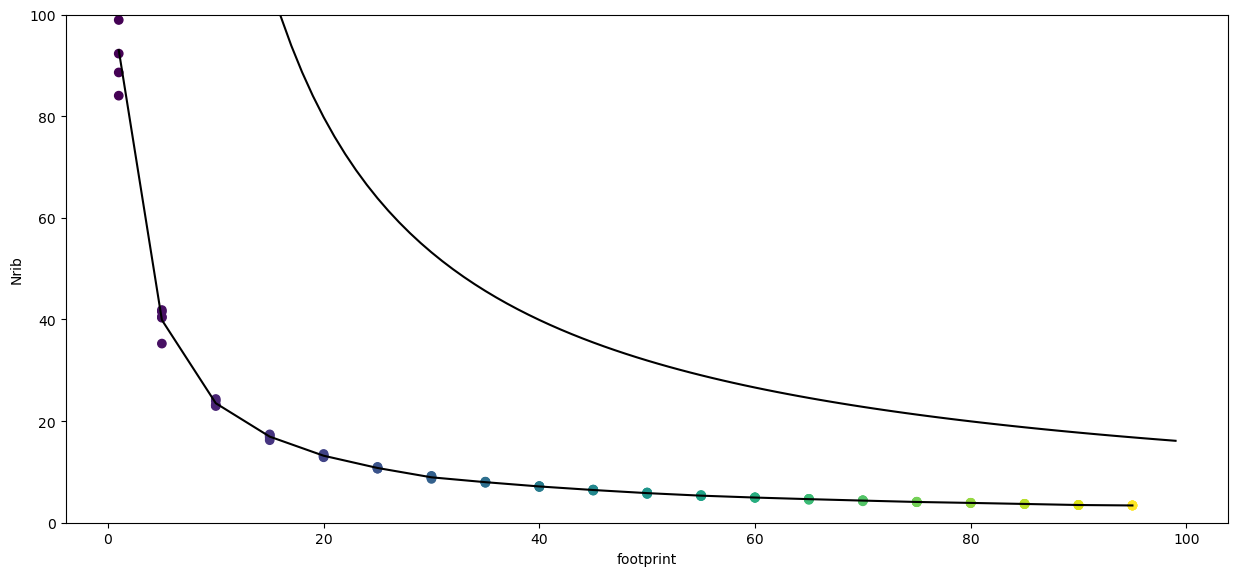

In [11]:
fig, ax = plt.subplots()

Nrib = results["ft"]
rho = (Nrib*results["foot_print"])/(prot_aa_size["similar_prot"] + prot_aa_size["32xsuntag"])

ax.scatter(results["foot_print"], 
           Nrib, 
           c=results["foot_print"] )


Nrib = results.groupby("foot_print").mean()["ft"]
rho = (Nrib*results.groupby("foot_print").mean().index)/(prot_aa_size["similar_prot"] + prot_aa_size["32xsuntag"])
ax.plot(results.groupby("foot_print").mean().index, 
           Nrib, color="black")

# max occupancy
# mo = (prot_aa_size["similar_prot"] + prot_aa_size["32xsuntag"])/results.groupby("foot_print").mean().index
# ax.plot(results.groupby("foot_print").mean().index, mo, color="black")

ft = [1]
ft.extend(np.arange(5,100,1))
ft = np.array(ft)
mo = (prot_aa_size["similar_prot"] + prot_aa_size["32xsuntag"])/ft
ax.plot(ft, mo, color="black")

fig.set_size_inches(15,6.6)
ax.set_ylim(0,100)
ax.set_xlabel("footprint")
ax.set_ylabel("Nrib")

# fig.savefig("footprint_density_theory.eps")

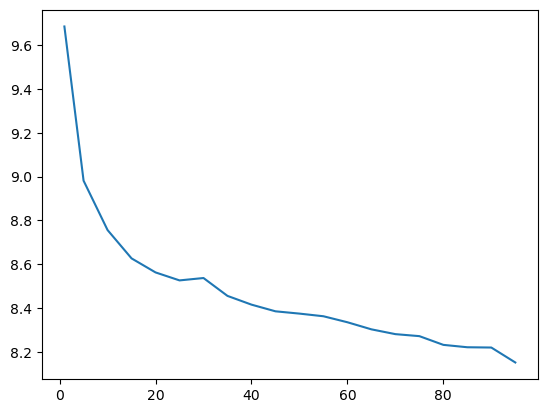

In [12]:
fig, ax = plt.subplots()

Nrib = results.groupby("foot_print").mean()["ft"]
rho = (Nrib*results.groupby("foot_print").mean().index)/(prot_aa_size["similar_prot"] + prot_aa_size["32xsuntag"])
ax.plot(results.groupby("foot_print").mean().index, 
           results.groupby("foot_print").mean()["elongation_r"]*(1-rho)/elongation_rate, )

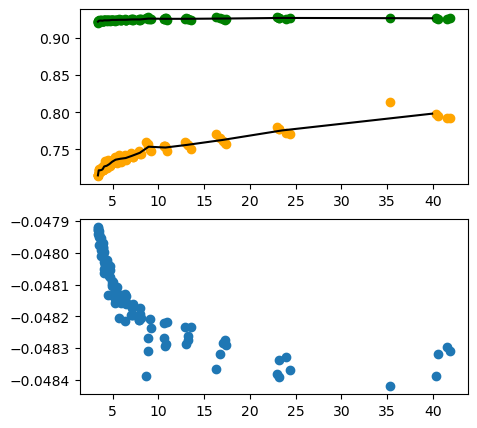

In [64]:
fig, axes = plt.subplots(nrows = 2)

Nrib = results.groupby("foot_print").mean()["ft"]
rho = (Nrib*results.groupby("foot_print").mean().index)/(prot_aa_size["similar_prot"] + prot_aa_size["32xsuntag"])
axes[0].plot(Nrib, 
           results[5:].groupby("foot_print").mean()["elongation_r"]*(1-rho)-elongation_rate, color= "black")


axes[0].plot(Nrib[1:], results.groupby("foot_print").mean()["elongation_r"][1:]-elongation_rate, color= "black")


Nrib = results["ft"]
rho = (Nrib*results["foot_print"])/(prot_aa_size["similar_prot"] + prot_aa_size["32xsuntag"])
axes[0].scatter(Nrib[5:],
           (results["elongation_r"][5:]*(1-rho[5:])-elongation_rate), color="orange")

Nrib = results["ft"]
rho = (Nrib*results["foot_print"])/(prot_aa_size["similar_prot"] + prot_aa_size["32xsuntag"])
axes[0].scatter(Nrib[5:],
           (results["elongation_r"][5:]-elongation_rate), color="green")


axes[1].scatter(Nrib[5:],
           (results["init_translation_r"][5:]-(0.05)))

fig.set_size_inches (5,5)
fig.savefig("footprint_k_c.eps")

In [54]:
results

,elongation_r,init_translation_r,dt,long_track,k,c,foot_print,ft,nb_point,id,length_track
0,1.028158,0.001568,30.0,120,0.041333,0.001568,1,101.183333,120,0,NaN
1,1.027000,0.001706,30.0,120,0.041286,0.001706,1,98.925000,120,1,3600.0
2,1.027844,0.001592,30.0,120,0.041320,0.001592,1,92.308333,120,2,3600.0
3,1.030449,0.001640,30.0,120,0.041425,0.001640,1,84.033333,120,3,3600.0
4,1.029079,0.001614,30.0,120,0.041370,0.001614,1,88.600000,120,4,3600.0
...,...,...,...,...,...,...,...,...,...,...,...
95,1.021925,0.002061,30.0,120,0.041082,0.002061,95,3.391667,120,0,3600.0
96,1.022310,0.002070,30.0,120,0.041098,0.002070,95,3.425000,120,1,3600.0
97,1.022264,0.002071,30.0,120,0.041096,0.002071,95,3.400000,120,2,3600.0
98,1.020701,0.002079,30.0,120,0.041033,0.002079,95,3.375000,120,3,3600.0


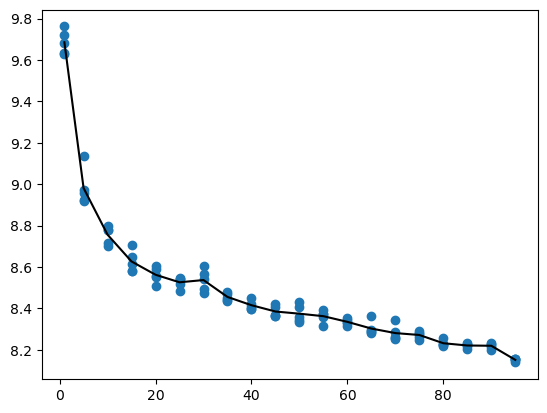

In [14]:
fig, ax = plt.subplots()

Nrib = results.groupby("foot_print").mean()["ft"]
rho = (Nrib*results.groupby("foot_print").mean().index)/(prot_aa_size["similar_prot"] + prot_aa_size["32xsuntag"])
ax.plot(results.groupby("foot_print").mean().index, 
           results.groupby("foot_print").mean()["elongation_r"]*(1-rho)/elongation_rate, color= "black")


Nrib = results["ft"]
rho = (Nrib*results["foot_print"])/(prot_aa_size["similar_prot"] + prot_aa_size["32xsuntag"])
ax.scatter(results["foot_print"],
           (results["elongation_r"]*(1-rho)/elongation_rate))

# ax.set_ylim(0,1)


# fig.savefig("nrib_elongation.eps")

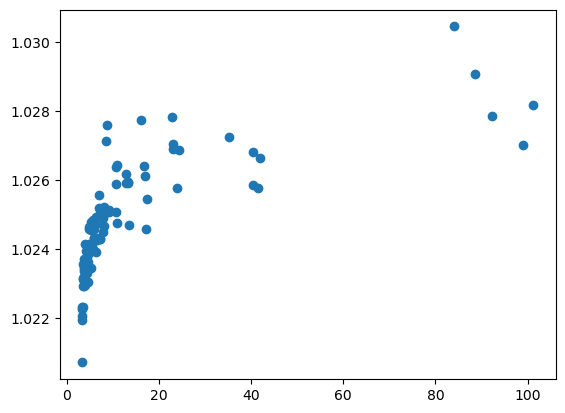

In [49]:
fig, ax = plt.subplots()

Nrib = results.groupby("foot_print").mean()["ft"]
rho = (Nrib*results.groupby("foot_print").mean().index)/(prot_aa_size["similar_prot"] + prot_aa_size["32xsuntag"])
#ax.plot(results.groupby("foot_print").mean().index, 
#           results.groupby("foot_print").mean()["elongation_r"]*(1-rho)/elongation_rate, color= "black")


Nrib = results["ft"]
rho = (Nrib*results["foot_print"])/(prot_aa_size["similar_prot"] + prot_aa_size["32xsuntag"])
ax.scatter(results["ft"],
           (results["elongation_r"]))

# ax.set_ylim(0,1)

# fig.savefig("footprint_elongation_no_correction.eps")